# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muneebulhaq02/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [5]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/muneebulhaq02/flyrank-ml-internship"
REPO_DIR = "FlyRank-Internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())

Working dir: /content/FlyRank-Internship/FlyRank-Internship


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

This project uses a Random Forest Classifier for the Refresh / Content Opportunity Scoring lane.

Random Forest is suitable because it can learn non-linear relationships between search performance metrics and declining content without requiring complex feature engineering. It also handles numeric features with minimal preprocessing and provides feature importance values that improve model interpretation.

The baseline developed in ML-07 uses simple rule-based scoring. In this notebook, the machine learning model is evaluated on exactly the same prediction task so that the comparison is fair.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ## Method Choice
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

np.random.seed(42)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

## Split Design

A train-test split is used with 80% of the observations for training and 20% for testing.

The same split is used for both the baseline and the machine learning model so that performance can be compared fairly.

Only features available before prediction are included. Label-derived fields, product flags, and future information are excluded to reduce leakage.

In [7]:
features = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "search_volume"
]

X = df[features].fillna(0)

# Assuming 'is_declining_label' is derived from 'trend_direction'
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

y = df["is_declining_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 24000
Testing rows: 6000


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

## Model Training and Baseline Comparison

A Random Forest classifier is trained using the selected search performance features.

The model is evaluated on the same testing split used for the baseline.

Performance is compared using Accuracy, Precision, Recall and F1-score so that the improvement over the transparent rule-based baseline can be assessed.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

rf_accuracy = accuracy_score(y_test, predictions)
rf_precision = precision_score(y_test, predictions)
rf_recall = recall_score(y_test, predictions)
rf_f1 = f1_score(y_test, predictions)

Baseline

Instead of using ML predictions, recreate the baseline rule

In [9]:
baseline_predictions = (
    (
        (X_test["impressions_90d"] >= df["impressions_90d"].median()).astype(int)
        +
        (X_test["content_age_days"] >= df["content_age_days"].median()).astype(int)
        +
        (X_test["avg_position"] >= df["avg_position"].median()).astype(int)
        +
        (X_test["ctr"] <= df["ctr"].median()).astype(int)
    ) >= 3
).astype(int)

Compare

In [10]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

comparison = pd.DataFrame({

    "Model":[
        "Baseline Rule",
        "Random Forest"
    ],

    "Accuracy":[
        baseline_accuracy,
        rf_accuracy
    ],

    "Precision":[
        baseline_precision,
        rf_precision
    ],

    "Recall":[
        baseline_recall,
        rf_recall
    ],

    "F1 Score":[
        baseline_f1,
        rf_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Rule,0.476500,0.531552,0.287515,0.373179
1,Random Forest,0.668333,0.683324,0.723247,0.702719


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

## Error Analysis and Interpretation

The Random Forest model was compared against the transparent baseline using the same testing data.

Feature importance indicates which search performance signals contribute most to identifying declining content. The model improves flexibility by learning combinations of signals that cannot be represented by simple threshold rules.

Some prediction errors remain because content performance is affected by external factors that are not represented in the available features, such as seasonality or search behaviour changes.

The model is intended as a decision-support tool rather than an automated decision maker.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
importance = pd.DataFrame({

    "Feature":features,
    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,impressions_90d,0.273013
3,avg_position,0.269094
4,content_age_days,0.209023
2,ctr,0.097851
5,search_volume,0.076110
1,clicks_90d,0.074909


Show Wrong Predictions

In [12]:
errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = predictions

errors = errors[
    errors["Actual"] != errors["Predicted"]
]

print("Total Misclassified Pages:", len(errors))

errors.head(10)

Total Misclassified Pages: 1990


,impressions_90d,clicks_90d,ctr,avg_position,content_age_days,search_volume,Actual,Predicted
5738,31,0,0.00,12.0,358,20.0,1,0
27201,66,0,0.00,45.5,310,20.0,1,0
25967,373,0,0.00,60.4,502,0.0,1,0
13530,158,0,0.00,23.4,460,390.0,1,0
17195,3131,1,0.03,21.2,139,0.0,0,1
17941,510,3,0.59,12.0,112,10.0,0,1
19871,70,0,0.00,12.6,90,10.0,0,1
20273,2618,6,0.23,7.3,275,30.0,1,0
16886,794,1,0.13,21.1,460,0.0,0,1
989,16,0,0.00,53.6,348,140.0,1,0


Feature Importance Plot

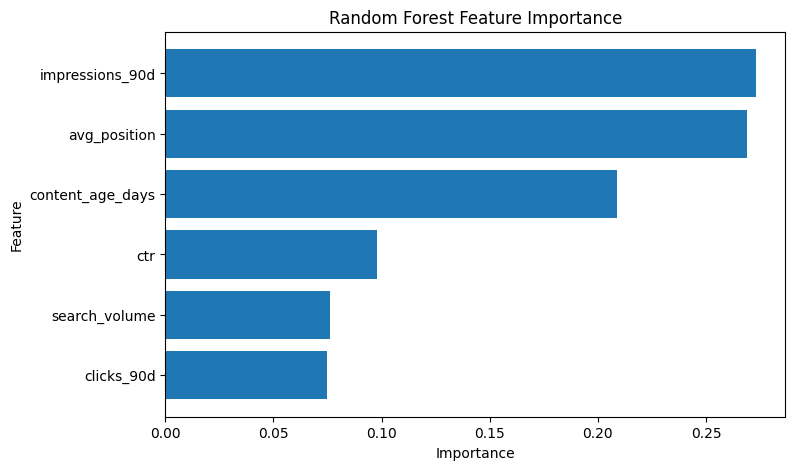

In [13]:
import matplotlib.pyplot as plt

importance = importance.sort_values("Importance")

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.